# Co-expression conservation: SEACell metacell network vs. bulk soybean network

Compares the metacell co-expression network built in
`../SEA_cells_construction/SEA_cells_run.ipynb` (400 SEACells as samples) against the
bulk-derived aggregate network `soybean_prioAggNet.hdf5`.

Method follows the Gillis lab **fine-to-bulk co-expression conservation** approach:
[`Coecoexpression_conservation_fine_to_bulk.ipynb`](https://github.com/gillislab/Coexpression_Proxies/blob/main/Coexpression_Network_Generation/Coecoexpression_conservation_fine_to_bulk.ipynb).

For every gene, take its **top 10 partners in the bulk network**, then ask where those
10 genes rank in that gene's column of the **metacell network**. If the metacell
network recovers the same partners they sit at the top of the ranking and the score is
near 1; if it ranks them randomly the score drops toward 0.

| Step | What happens |
| --- | --- |
| 1 | Subset `All_Plants.gene_info` to *Glycine max* (taxid 3847) |
| 2 | Map `Glyma.*.Wm82.a4.v1` to the bulk network's NCBI names via the `LocusTag` field |
| 3 | Load both networks restricted to the shared genes, in matching order |
| 4 | Zero the diagonals; build the top-10 partner mask from the bulk network |
| 5 | Rank each column of the metacell network; `mask . ranks`; take the diagonal |
| 6 | Normalise, take the median, plot the distribution |

**Reference point:** the same procedure applied to Arabidopsis (fine single-cell
pseudobulk vs. bulk CoCoCoNet) gave a median conservation of **0.863**.

In [1]:
import os
import h5py
import numpy as np
import pandas as pd
import scipy.sparse as sp
import scipy.stats as sci
import seaborn as sns
import matplotlib.pyplot as plt

RANDOM_SEED = 476
np.random.seed(RANDOM_SEED)

GENE_INFO_ALL = r"C:\Users\mikep\Data\NCBI\All_Plants.gene_info"
GENE_INFO_SOY = r"C:\Users\mikep\Data\NCBI\Glycine_max_3847.gene_info.csv"
BULK_NET = r"C:\Users\mikep\Data\Soybean\Soybean_reference_info\soybean_prioAggNet.hdf5"
META_NET = (
    r"C:\Users\mikep\Data\Soybean\Metacells_approaches\SEA_cells"
    r"\SEA_cells_400_metacell_coexpression_network.h5"
)
SCORES_OUT = "metacell_vs_bulk_conservation_scores.csv"

GLYCINE_MAX_TAXID = 3847
TOP_N_PARTNERS = 10  # size of the bulk-network partner set, per the reference notebook
READ_CHUNK_ROWS = 500  # rows per slab when pulling the bulk network off disk
DOT_CHUNK_COLS = 1000  # columns per chunk in the mask-by-ranks product

c:\Users\mikep\miniconda3\envs\Seacells\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 2.2.0 when it was built against 2.1.0, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


## Step 1 — subset NCBI `gene_info` to *Glycine max*

`All_Plants.gene_info` is ~1.5 GB, so it is streamed in chunks, filtered to taxid 3847,
and cached to CSV. Re-runs read the cache.

In [2]:
if os.path.exists(GENE_INFO_SOY):
    gene_info = pd.read_csv(GENE_INFO_SOY, dtype=str)
    print(f"Loaded cached Glycine max gene_info: {len(gene_info):,} rows")
else:
    print(f"Streaming {GENE_INFO_ALL} and filtering to taxid {GLYCINE_MAX_TAXID} ...")
    kept = []
    for chunk in pd.read_csv(
        GENE_INFO_ALL, sep="\t", dtype=str, chunksize=500_000, low_memory=False
    ):
        chunk = chunk.rename(columns={"#tax_id": "tax_id"})
        kept.append(chunk[chunk["tax_id"] == str(GLYCINE_MAX_TAXID)])
    gene_info = pd.concat(kept, ignore_index=True)
    gene_info.to_csv(GENE_INFO_SOY, index=False)
    print(f"Cached {len(gene_info):,} Glycine max rows to {GENE_INFO_SOY}")

print(f"\ngene_info columns: {list(gene_info.columns)}")
gene_info[["GeneID", "Symbol", "LocusTag", "description", "type_of_gene"]].head()

Loaded cached Glycine max gene_info: 59,141 rows

gene_info columns: ['tax_id', 'GeneID', 'Symbol', 'LocusTag', 'Synonyms', 'dbXrefs', 'chromosome', 'map_location', 'description', 'type_of_gene', 'Symbol_from_nomenclature_authority', 'Full_name_from_nomenclature_authority', 'Nomenclature_status', 'Other_designations', 'Modification_date', 'Feature_type']


,GeneID,Symbol,LocusTag,description,type_of_gene
0,547449,LOC547449,GLYMA_20G164700v4,class III acidic endochitinase,protein-coding
1,547450,SRC1,GLYMA_17G187600v4,src1 protein,protein-coding
2,547451,SRC2,GLYMA_15G152900v4,SOYBEAN GENE REGULATED BY COLD 2,protein-coding
3,547452,GY5,GLYMA_13G123500v4,glycinin gy5,protein-coding
4,547453,UR9,GLYMA_10G121524v4,uricase-2 isozyme 1,protein-coding


## Step 2 — map `Glyma` IDs to the bulk network's gene names

The two networks use different naming schemes and share **zero** names directly:

- metacell network: Phytozome/JGI, e.g. `Glyma.01G161700.Wm82.a4.v1`
- bulk network: NCBI, e.g. `LOC100808170` (38,429 of them) or a gene symbol like `MYB128` (2,396)

`gene_info`'s **`LocusTag`** column is the bridge — it carries Wm82.**a4** gene models
(`GLYMA_01G161700v4`), the same assembly the metacell network is built on, so no
cross-assembly liftover is needed. The conversion is purely textual:

```
Glyma.01G161700.Wm82.a4.v1  ->  GLYMA_01G161700v4  ->  Symbol (LOC100808170 / MYB128)
```

In [3]:
def glyma_to_locustag(gene):
    """Glyma.01G161700.Wm82.a4.v1 -> GLYMA_01G161700v4 (the NCBI LocusTag form)."""
    core = gene.split(".Wm82")[0]  # Glyma.01G161700
    return "GLYMA_" + core.split(".", 1)[1] + "v4"


# gene_info can carry a LocusTag more than once; keep the first so the map stays 1:1.
locus_to_symbol = (
    gene_info.dropna(subset=["LocusTag", "Symbol"])
    .drop_duplicates(subset="LocusTag", keep="first")
    .set_index("LocusTag")["Symbol"]
    .to_dict()
)
print(f"LocusTag -> Symbol entries: {len(locus_to_symbol):,}")

with h5py.File(META_NET, "r") as handle:
    meta_genes = handle["genes"].asstr()[:]
with h5py.File(BULK_NET, "r") as handle:
    bulk_genes = handle["row"].asstr()[:]
    assert (handle["row"][:] == handle["col"][:]).all(), "bulk net rows != cols"

print(f"metacell network: {len(meta_genes):,} genes  e.g. {meta_genes[0]}")
print(f"bulk network:     {len(bulk_genes):,} genes  e.g. {bulk_genes[0]}")
print(f"direct name overlap: {len(set(meta_genes) & set(bulk_genes)):,}")

bulk_position = {gene: i for i, gene in enumerate(bulk_genes)}

# Walk the metacell genes and keep those that reach a gene present in the bulk network.
pairs = []  # (metacell gene, bulk gene, metacell index, bulk index)
no_locustag, no_bulk_entry = [], []
for meta_idx, gene in enumerate(meta_genes):
    symbol = locus_to_symbol.get(glyma_to_locustag(gene))
    if symbol is None:
        no_locustag.append(gene)
    elif symbol not in bulk_position:
        no_bulk_entry.append(gene)
    else:
        pairs.append((gene, symbol, meta_idx, bulk_position[symbol]))

mapping = pd.DataFrame(
    pairs, columns=["metacell_gene", "bulk_gene", "meta_idx", "bulk_idx"]
)
print(
    f"\nMapped {len(mapping):,} of {len(meta_genes):,} metacell genes "
    f"({len(mapping) / len(meta_genes):.1%})"
)
print(f"  no LocusTag match in gene_info: {len(no_locustag):,}")
print(f"  mapped but absent from bulk net: {len(no_bulk_entry):,}")

# Guard against many-to-one collapse, which would put duplicate rows in the network.
collisions = mapping["bulk_gene"].duplicated().sum()
if collisions:
    print(f"  dropping {collisions:,} metacell genes sharing a bulk gene")
    mapping = mapping.drop_duplicates(subset="bulk_gene", keep="first")

# h5py fancy indexing needs strictly increasing indices, so order by bulk position.
mapping = mapping.sort_values("bulk_idx").reset_index(drop=True)
n_shared = len(mapping)
meta_idx = mapping["meta_idx"].to_numpy()
bulk_idx = mapping["bulk_idx"].to_numpy()
shared_genes = mapping["metacell_gene"].to_numpy()
print(f"\nShared gene set for the comparison: {n_shared:,} genes")
mapping.head()

LocusTag -> Symbol entries: 40,814
metacell network: 23,277 genes  e.g. Glyma.01G161700.Wm82.a4.v1
bulk network:     40,825 genes  e.g. LOC100808170
direct name overlap: 0

Mapped 21,441 of 23,277 metacell genes (92.1%)
  no LocusTag match in gene_info: 1,787
  mapped but absent from bulk net: 49

Shared gene set for the comparison: 21,441 genes


,metacell_gene,bulk_gene,meta_idx,bulk_idx
0,Glyma.01G000322.Wm82.a4.v1,LOC106794262,17238,2
1,Glyma.01G000400.Wm82.a4.v1,LOC100781438,16780,3
2,Glyma.01G000600.Wm82.a4.v1,LOC100788220,255,4
3,Glyma.01G000900.Wm82.a4.v1,LOC100779643,16752,5
4,Glyma.01G001000.Wm82.a4.v1,LOC100499919,4607,6


## Step 3 — load both networks over the shared genes

The bulk `agg` matrix is 40,825 x 40,825 float64 — **13.3 GB** if read whole, which is
what `CococoNet_reader.read_cococonet` does. Instead each network is read in row slabs
and subset to the shared genes on the way in, so only the ~1.8 GB float32 submatrix is
ever held. Both come out in the same gene order.

In [4]:
def read_network_subset(path, dataset, index, chunk_rows=READ_CHUNK_ROWS):
    """Read a symmetric gene x gene subset without materialising the full matrix.

    `index` may be in any order; h5py needs strictly increasing row indices, so rows are
    fetched sorted and written straight to their destination slots.
    """
    order = np.argsort(index)
    sorted_index = index[order]
    size = len(index)
    out = np.empty((size, size), dtype=np.float32)
    with h5py.File(path, "r") as handle:
        dset = handle[dataset]
        for start in range(0, size, chunk_rows):
            stop = min(start + chunk_rows, size)
            block = dset[sorted_index[start:stop], :]
            out[order[start:stop]] = block[:, index].astype(np.float32)
    return out


print(
    f"Reading bulk network subset ({n_shared:,} x {n_shared:,}, "
    f"~{n_shared ** 2 * 4 / 1e9:.2f} GB) ..."
)
bulk_sub = read_network_subset(BULK_NET, "agg", bulk_idx)
print(
    f"  values span {bulk_sub.min():.6f} to {bulk_sub.max():.6f}, "
    f"median {np.median(bulk_sub):.4f}"
)

# The reference notebook zeroes self-edges with .replace(1, 0), which also clobbers any
# off-diagonal edge that happens to sit at exactly 1.0. Zero the diagonal explicitly
# instead, and report what the blunt version would have caught.
off_diagonal_ones = int((bulk_sub == 1.0).sum()) - n_shared
print(
    f"  off-diagonal edges at exactly 1.0: {off_diagonal_ones:,} "
    f"(kept here, dropped by .replace(1, 0))"
)
np.fill_diagonal(bulk_sub, 0.0)

Reading bulk network subset (21,441 x 21,441, ~1.84 GB) ...
  values span 0.000000 to 1.000000, median 0.7699
  off-diagonal edges at exactly 1.0: 0 (kept here, dropped by .replace(1, 0))


## Step 4 — top-10 partner mask from the bulk network

For each gene, the 10 strongest partners in the bulk network. Stored sparse (10 entries
per gene) rather than as the dense genes x genes frame the reference notebook builds —
identical contents, ~1.8 GB less memory.

In [5]:
# Per column, the row indices of the TOP_N_PARTNERS largest edges.
top_partners = np.argpartition(-bulk_sub, TOP_N_PARTNERS, axis=0)[:TOP_N_PARTNERS, :]
del bulk_sub  # mask is all that is needed from here on

mask = sp.csr_matrix(
    (
        np.ones(n_shared * TOP_N_PARTNERS, dtype=np.float32),
        (np.repeat(np.arange(n_shared), TOP_N_PARTNERS), top_partners.T.ravel()),
    ),
    shape=(n_shared, n_shared),
)
print(f"Top-{TOP_N_PARTNERS} mask: {mask.shape[0]:,} genes x {mask.nnz:,} edges")
print(
    f"  edges per gene: min={mask.getnnz(axis=1).min()}, "
    f"max={mask.getnnz(axis=1).max()}"
)

Top-10 mask: 21,441 genes x 214,410 edges
  edges per gene: min=10, max=10


In [6]:
print(f"Reading metacell network subset ({n_shared:,} x {n_shared:,}) ...")
meta_sub = read_network_subset(META_NET, "network", meta_idx)

# The reference notebook clips its network at 0 because it feeds in raw Spearman values.
# Ours is already rank standardised onto (0, 1], so the clip is a no-op -- and since the
# score depends only on within-column ranks, the rank standardisation itself cannot
# change the result either way.
negative_edges = int((meta_sub < 0).sum())
print(f"  negative edges needing a clip: {negative_edges:,}")
np.clip(meta_sub, 0, None, out=meta_sub)
np.fill_diagonal(meta_sub, 0.0)

# Rank down each column, in place and in chunks to avoid a float64 copy of the matrix.
print("Ranking each column of the metacell network ...")
for start in range(0, n_shared, DOT_CHUNK_COLS):
    stop = min(start + DOT_CHUNK_COLS, n_shared)
    meta_sub[:, start:stop] = sci.rankdata(
        meta_sub[:, start:stop], method="average", axis=0
    ).astype(np.float32)
print(f"  ranks span {meta_sub.min():.0f} to {meta_sub.max():.0f}")

Reading metacell network subset (21,441 x 21,441) ...
  negative edges needing a clip: 0
Ranking each column of the metacell network ...
  ranks span 1 to 21441


## Step 5 — conservation score

`mask . ranks` gives a genes x genes matrix whose **diagonal** is the quantity of
interest: for gene *g*, the summed rank — inside the metacell network's column *g* — of
the 10 genes that are *g*'s strongest partners in the bulk network.

The floor is `2 + 3 + ... + 11 = 65`: the zeroed self-edge always takes rank 1, so the
10 partners can do no better than ranks 2 through 11. The reference notebook then
divides by the spread of the **whole** matrix, so the full product is swept in column
chunks to recover its global min and max without ever holding all of it.

In [10]:
# Lowest attainable rank sum: rank 1 belongs to the zeroed self-edge.
MINIMUM_RANK_SUM = sum(range(2, TOP_N_PARTNERS + 2))
print(f"Minimum attainable rank sum: {MINIMUM_RANK_SUM}")

diagonal = np.empty(n_shared, dtype=np.float64)
global_max, global_min = -np.inf, np.inf

print("Computing mask . ranks in column chunks ...")
for start in range(0, n_shared, DOT_CHUNK_COLS):
    stop = min(start + DOT_CHUNK_COLS, n_shared)
    block = mask.dot(meta_sub[:, start:stop])
    global_max = max(global_max, float(block.max()))
    global_min = min(global_min, float(block.min()))
    diagonal[start:stop] = block[np.arange(start, stop), np.arange(stop - start)]

print(f"  full product spans {global_min:,.0f} to {global_max:,.0f}")

score_range = global_max - global_min
conservation_scores = pd.Series(
    (diagonal - MINIMUM_RANK_SUM) / score_range,
    index=shared_genes,
    name="conservation_score",
)

median_score = float(conservation_scores.median())
print(f"\nMedian conservation score: {median_score:.4f}")
print(
    f"  mean {conservation_scores.mean():.4f}, "
    f"IQR {conservation_scores.quantile(0.25):.4f}-"
    f"{conservation_scores.quantile(0.75):.4f}"
)
print(f"  range {conservation_scores.min():.4f} to {conservation_scores.max():.4f}")
print(f"\nArabidopsis fine-to-bulk reference median: 0.8626")
conservation_scores.head()

Minimum attainable rank sum: 65
Computing mask . ranks in column chunks ...
  full product spans 145 to 214,304

Median conservation score: 0.7301
  mean 0.7219, IQR 0.6071-0.8516
  range 0.1097 to 1.0003

Arabidopsis fine-to-bulk reference median: 0.8626


Glyma.01G000322.Wm82.a4.v1    0.693186
Glyma.01G000400.Wm82.a4.v1    0.538558
Glyma.01G000600.Wm82.a4.v1    0.464221
Glyma.01G000900.Wm82.a4.v1    0.583403
Glyma.01G001000.Wm82.a4.v1    0.952311
Name: conservation_score, dtype: float64

## Step 6 — distribution of conservation scores

Same figure as the reference notebook (`sns.histplot` over the diagonal), with the
median and the Arabidopsis reference median marked.

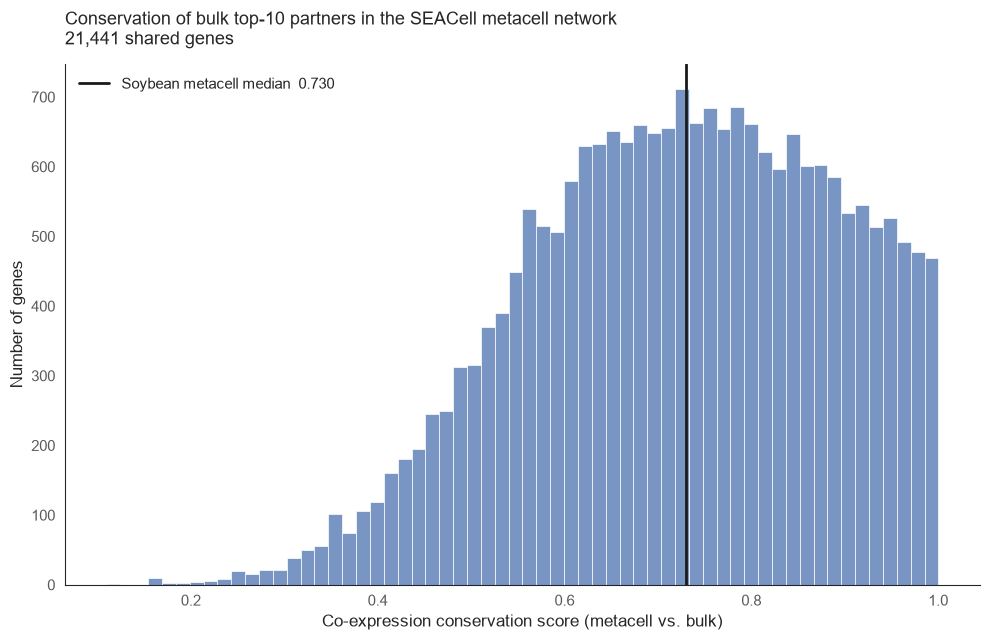

In [12]:
ARABIDOPSIS_REFERENCE_MEDIAN = 0.8626  # fine-to-bulk median from the reference notebook

sns.set_style("white")
fig, ax = plt.subplots(figsize=(10, 6.5))

sns.histplot(
    conservation_scores,
    bins=60,
    color="#4C72B0",
    edgecolor="white",
    linewidth=0.5,
    ax=ax,
)

# Reference lines are labelled in a legend rather than inline: at 0.73 and 0.86 they sit
# too close together, and over the tallest bars, for inline text to stay legible.
ax.axvline(
    median_score,
    color="#1A1A1A",
    linestyle="-",
    linewidth=2,
    label=f"Soybean metacell median  {median_score:.3f}",
)
# ax.axvline(
#     ARABIDOPSIS_REFERENCE_MEDIAN,
#     color="#8C8C8C",
#     linestyle="--",
#     linewidth=2,
#     label=f"Arabidopsis fine-to-bulk reference  {ARABIDOPSIS_REFERENCE_MEDIAN:.3f}",
# )

ax.set_xlabel("Co-expression conservation score (metacell vs. bulk)", fontsize=12)
ax.set_ylabel("Number of genes", fontsize=12)
ax.set_title(
    f"Conservation of bulk top-{TOP_N_PARTNERS} partners in the SEACell metacell "
    f"network\n{n_shared:,} shared genes",
    fontsize=13,
    loc="left",
    pad=14,
)
ax.legend(loc="upper left", frameon=False, fontsize=11)
ax.grid(False)
sns.despine(ax=ax)
ax.tick_params(labelsize=11, colors="#5A5A5A")
fig.tight_layout()
plt.show()

In [9]:
conservation_scores.sort_values(ascending=False).to_csv(SCORES_OUT, header=True)
print(f"Saved {len(conservation_scores):,} per-gene scores to {SCORES_OUT}")

print("\nMost conserved genes:")
print(conservation_scores.nlargest(10).round(4).to_string())
print("\nLeast conserved genes:")
print(conservation_scores.nsmallest(10).round(4).to_string())

Saved 21,441 per-gene scores to metacell_vs_bulk_conservation_scores.csv

Most conserved genes:
Glyma.07G185500.Wm82.a4.v1    1.0003
Glyma.15G221300.Wm82.a4.v1    1.0002
Glyma.09G155500.Wm82.a4.v1    1.0001
Glyma.16G211700.Wm82.a4.v1    1.0001
Glyma.14G063700.Wm82.a4.v1    1.0000
Glyma.08G181000.Wm82.a4.v1    1.0000
Glyma.16G033700.Wm82.a4.v1    1.0000
Glyma.18G106300.Wm82.a4.v1    0.9999
Glyma.09G135700.Wm82.a4.v1    0.9999
Glyma.08G350800.Wm82.a4.v1    0.9998

Least conserved genes:
Glyma.08G047800.Wm82.a4.v1    0.1097
Glyma.13G315900.Wm82.a4.v1    0.1572
Glyma.12G185600.Wm82.a4.v1    0.1587
Glyma.07G212700.Wm82.a4.v1    0.1598
Glyma.03G176100.Wm82.a4.v1    0.1626
Glyma.17G092400.Wm82.a4.v1    0.1657
Glyma.08G221600.Wm82.a4.v1    0.1659
Glyma.09G059900.Wm82.a4.v1    0.1669
Glyma.12G096900.Wm82.a4.v1    0.1675
Glyma.20G130200.Wm82.a4.v1    0.1689
